In [1]:
from typing import List, TypedDict
import re

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel
from dotenv import load_dotenv

load_dotenv()

C:\Users\ABHIMANU\AppData\Local\Temp\ipykernel_14232\1606832313.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader
d:\Lang_Graph_Concepts\langgraphvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


True

In [2]:
docs = PyPDFLoader("../islr.pdf").load()

In [3]:
len(docs)

441

In [4]:
chunks = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)

for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

In [5]:
len(chunks)

1429

In [6]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
vector_store = FAISS.from_documents(chunks, embeddings)
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 4})

In [7]:
from langchain_groq import ChatGroq
llm = ChatGroq(model="openai/gpt-oss-120b")

In [8]:
class State(TypedDict):
    question : str
    documents : List[Document]

    strips: List[str]            # output of decomposition (sentence strips)
    kept_strips: List[str]       # after filtering (kept sentences)
    refined_context: str 
    
    answer : str

In [9]:
def retrieve(state):
    q = state["question"]
    return {"documents": retriever.invoke(q)}

In [23]:
def decompose_to_sentences(text : str):
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip())>20]

class KeepOrDrop(BaseModel):
    keep: bool

prompt = ChatPromptTemplate.from_messages(
    [
         (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

filter_chain = prompt|llm.with_structured_output(KeepOrDrop)

def refine(state: State):
    question = state['question']

    context = "\n\n".join(d.page_content for d in state['documents']).strip()

    strips = decompose_to_sentences(context)

    kept : List = []

    for s in strips:
        if filter_chain.invoke({'question':question, 'sentence': s}).keep :
            kept.append(s)
    
    refined_context = "\n".join(kept).strip()

    return {'strips':strips, 'kept_strips':kept, 'refined_context':refined_context}

In [24]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful ML tutor. Answer ONLY using the provided refined bullets.\n"
            "If the bullets are empty or insufficient, say: 'I don't know based on the provided books.'",
        ),
        ("human", "Question: {question}\n\nRefined context:\n{refined_context}"),
    ]
)

def generate(state: State):
    out = (answer_prompt|llm).invoke({'question':state['question'], 'refined_context':state['refined_context']})
    return {'answer': out.content}

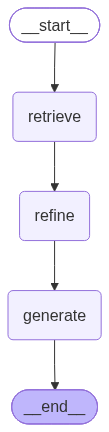

In [25]:
g = StateGraph(State)

g.add_node("retrieve", retrieve)
g.add_node("refine", refine)
g.add_node("generate", generate)

g.add_edge(START, "retrieve")
g.add_edge("retrieve", "refine")
g.add_edge("refine", "generate")
g.add_edge("generate", END)

app = g.compile()

app

In [26]:
res = app.invoke({
    "question": "What is linear regression?", #Explain the bias–variance tradeoff
    "docs": [],
    "strips": [],
    "kept_strips": [],
    "refined_context": "",
    "answer": ""
})

In [27]:
import textwrap

out = textwrap.fill(res['answer'], width=80)
print(out)

Linear regression is a straightforward supervised‑learning technique for
predicting a quantitative response \(Y\) from one (or more) predictor variables.
In its simplest form—**simple linear regression**—it assumes an approximately
linear relationship between a single predictor \(X\) and the response, expressed
mathematically as    \[ Y \approx \beta_0 + \beta_1 X, \]  where \(\beta_0\)
(intercept) and \(\beta_1\) (slope) are unknown coefficients that define the
population regression line.   The method fits these coefficients—typically by
the **least‑squares** criterion—to best approximate the observed data, enabling
predictions such as “sales ≈ \(\beta_0 + \beta_1 \times\) TV”.    Thus, linear
regression is a widely used, classic approach for estimating and predicting
quantitative outcomes.


In [28]:
print(res['documents'][0].page_content)
print("*"*50)
print(res['documents'][1].page_content)
print("*"*50)
print(res['documents'][2].page_content)
print("*"*50)
print(res['documents'][3].page_content)

3
Linear Regression
This chapter is about linear regression, a very simple approach for
supervised learning. In particular, linear regression is a useful tool for pre-
dicting a quantitative response. Linear regression has been around for a
long time and is the topic of innumerable textbooks. Though it may seem
somewhat dull compared to some of the more modern statistical learning
approaches described in later chapters of this book, linear regression is still
a useful and widely used statistical learning method. Moreover, it serves
as a good jumping-oﬀ point for newer approaches: as we will see in later
chapters, many fancy statistical learning approaches can be seen as gener-
alizations or extensions of linear regression. Consequently, the importance
of having a good understanding of linear regression before studying more
**************************************************
3.1 Simple Linear Regression 61
3.1 Simple Linear Regression
Simple linear regressionlives up to its name: it is a

In [29]:
rf = textwrap.fill(res['refined_context'], width=80)
print(rf)

3 Linear Regression This chapter is about linear regression, a very simple
approach for supervised learning. In particular, linear regression is a useful
tool for pre- dicting a quantitative response. Though it may seem somewhat dull
compared to some of the more modern statistical learning approaches described in
later chapters of this book, linear regression is still a useful and widely used
statistical learning method. Consequently, the importance of having a good
understanding of linear regression before studying more 3.1 Simple Linear
Regression 61 3.1 Simple Linear Regression Simple linear regressionlives up to
its name: it is a very straightforwardsimple linear regressionapproach for
predicting a quantitative responseY on the basis of a sin- gle predictor
variableX. It assumes that there is approximately a linear relationship between
X and Y. Mathematically, we can write this linear relationship as Y ≈ β0 +β1X.
Then we can regresssales onto TV by ﬁtting the model sales ≈ β0 +β1 ×

In [30]:
res['strips']

['3 Linear Regression This chapter is about linear regression, a very simple approach for supervised learning.',
 'In particular, linear regression is a useful tool for pre- dicting a quantitative response.',
 'Linear regression has been around for a long time and is the topic of innumerable textbooks.',
 'Though it may seem somewhat dull compared to some of the more modern statistical learning approaches described in later chapters of this book, linear regression is still a useful and widely used statistical learning method.',
 'Moreover, it serves as a good jumping-oﬀ point for newer approaches: as we will see in later chapters, many fancy statistical learning approaches can be seen as gener- alizations or extensions of linear regression.',
 'Consequently, the importance of having a good understanding of linear regression before studying more 3.1 Simple Linear Regression 61 3.1 Simple Linear Regression Simple linear regressionlives up to its name: it is a very straightforwardsimple l

In [31]:
res['kept_strips']

['3 Linear Regression This chapter is about linear regression, a very simple approach for supervised learning.',
 'In particular, linear regression is a useful tool for pre- dicting a quantitative response.',
 'Though it may seem somewhat dull compared to some of the more modern statistical learning approaches described in later chapters of this book, linear regression is still a useful and widely used statistical learning method.',
 'Consequently, the importance of having a good understanding of linear regression before studying more 3.1 Simple Linear Regression 61 3.1 Simple Linear Regression Simple linear regressionlives up to its name: it is a very straightforwardsimple linear regressionapproach for predicting a quantitative responseY on the basis of a sin- gle predictor variableX.',
 'It assumes that there is approximately a linear relationship between X and Y.',
 'Mathematically, we can write this linear relationship as Y ≈ β0 +β1X.',
 'Then we can regresssales onto TV by ﬁtting 